In [3]:
!ls ../results/workflow_architecture

('../results/workflow_architecture/agentic_architecture.png',
 '../results/workflow_architecture/agentic_architecture.pdf',
 '../results/workflow_architecture/agentic_pipeline_flow.png',
 '../results/workflow_architecture/agentic_pipeline_flow.pdf')

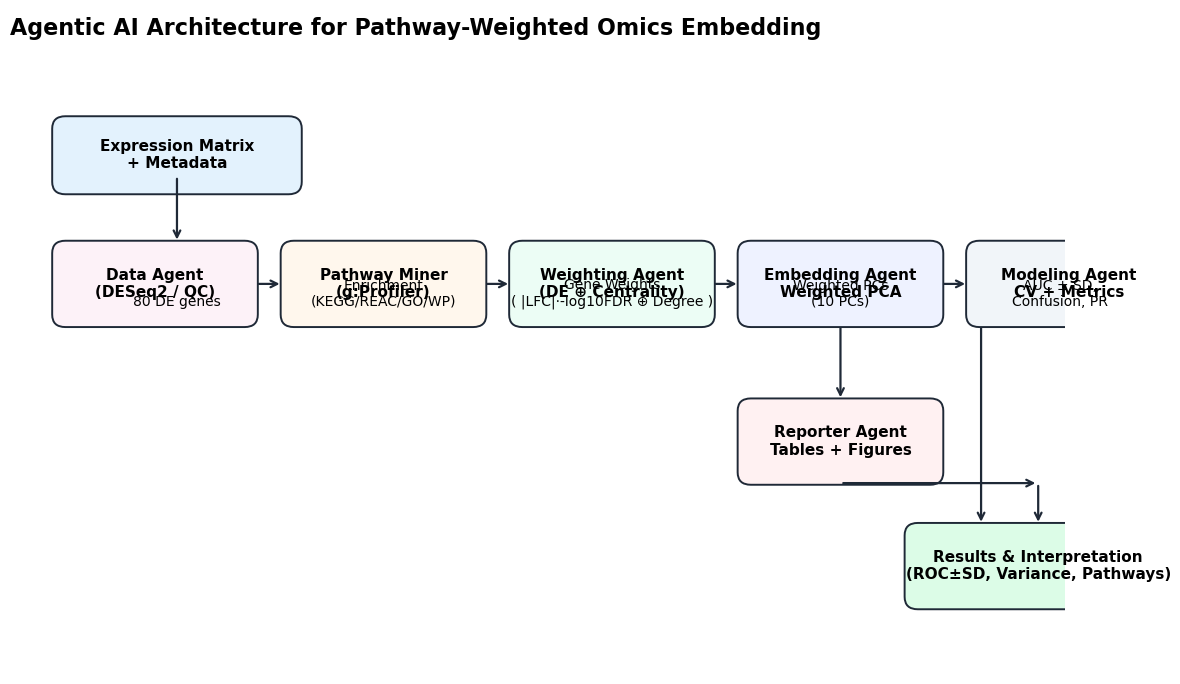

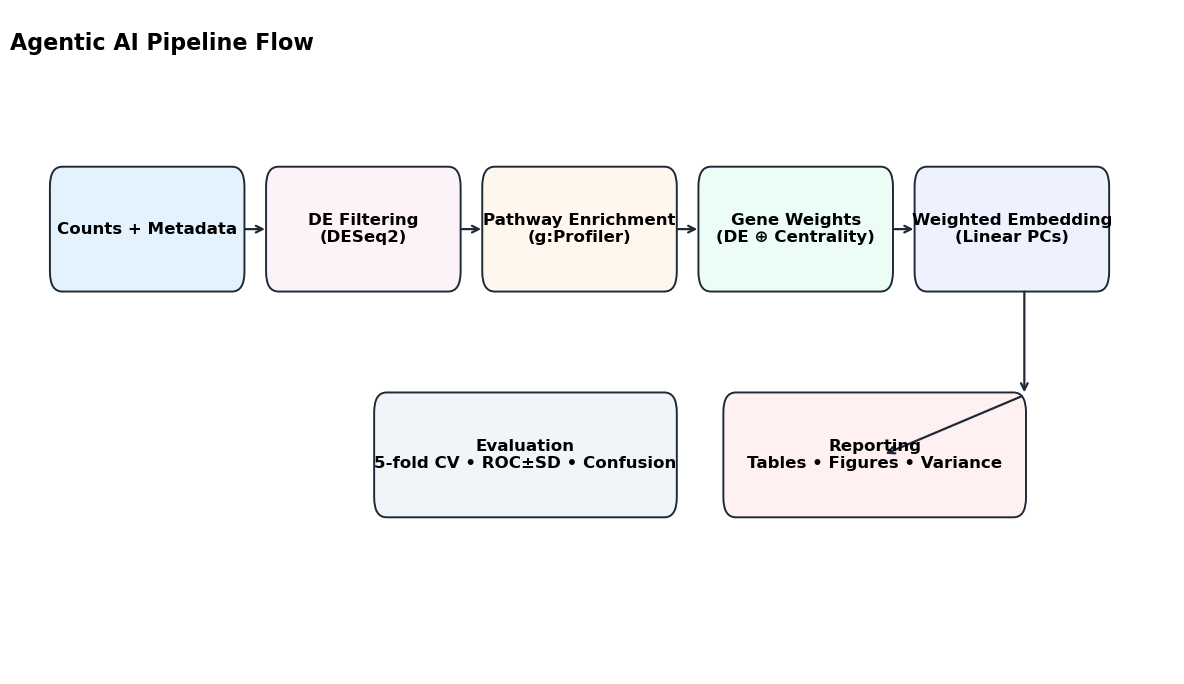

In [4]:
# Create two clean, modern architecture figures using matplotlib (no external deps).
# 1) Agentic AI Architecture (block diagram)
# 2) Pipeline Flowchart (left-to-right sequence)
#
# Files saved as both PDF and PNG in output_dir for easy inclusion in papers/posters.

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib import patheffects as pe

output_dir ='../results/workflow_architecture'

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "font.size": 12,
    "axes.axisbelow": True
})

def rounded_box(ax, xy, w, h, text, fc="#F2F5FA", ec="#1F2937", lw=1.4, radius=0.15, txtsize=12, bold=False):
    x, y = xy
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle=f"round,pad=0.02,rounding_size={radius}",
                         linewidth=lw, edgecolor=ec, facecolor=fc)
    ax.add_patch(box)
    kw = dict(ha="center", va="center", fontsize=txtsize)
    if bold:
        kw["fontweight"] = "bold"
    ax.text(x + w/2, y + h/2, text, **kw)
    return box

def arrow(ax, start, end, color="#1F2937", lw=1.6, style="->", rad=0.0):
    a = FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=12,
                        linewidth=lw, color=color, connectionstyle=f"arc3,rad={rad}")
    ax.add_patch(a)
    return a

# ===== Figure 1: Agentic AI Architecture (Block Diagram) =====
fig1, ax1 = plt.subplots()
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 8)
ax1.axis("off")

# Title
ax1.text(0, 7.7, "Agentic AI Architecture for Pathway-Weighted Omics Embedding", fontsize=16, fontweight="bold")

# Inputs
raw_box = rounded_box(ax1, (0.5, 5.8), 2.8, 0.9, "Expression Matrix\n+ Metadata", fc="#E3F2FD", txtsize=11, bold=True)

# Agents row
y_agents = 4.2
w, h = 2.3, 1.0

data_agent   = rounded_box(ax1, (0.5, y_agents), w, h, "Data Agent\n(DESeq2 / QC)", fc="#FDF2F8", txtsize=11, bold=True)
path_agent   = rounded_box(ax1, (3.1, y_agents), w, h, "Pathway Miner\n(g:Profiler)", fc="#FFF7ED", txtsize=11, bold=True)
weight_agent = rounded_box(ax1, (5.7, y_agents), w, h, "Weighting Agent\n(DE ⊕ Centrality)", fc="#ECFDF5", txtsize=11, bold=True)
embed_agent  = rounded_box(ax1, (8.3, y_agents), w, h, "Embedding Agent\nWeighted PCA", fc="#EEF2FF", txtsize=11, bold=True)
model_agent  = rounded_box(ax1, (10.9, y_agents), w, h, "Modeling Agent\nCV + Metrics", fc="#F1F5F9", txtsize=11, bold=True)

# Reporter (below)
reporter = rounded_box(ax1, (8.3, 2.3), w, h, "Reporter Agent\nTables + Figures", fc="#FFF1F2", txtsize=11, bold=True)

# Outputs
out_box = rounded_box(ax1, (10.2, 0.8), 3.0, 1.0, "Results & Interpretation\n(ROC±SD, Variance, Pathways)", fc="#DCFCE7", txtsize=11, bold=True)

# Arrows
arrow(ax1, (1.9, 6.0), (1.9, 5.2))
arrow(ax1, (2.8, y_agents+0.5), (3.1, y_agents+0.5))
arrow(ax1, (5.4, y_agents+0.5), (5.7, y_agents+0.5))
arrow(ax1, (8.0, y_agents+0.5), (8.3, y_agents+0.5))
arrow(ax1, (10.6, y_agents+0.5), (10.9, y_agents+0.5))

# Down to reporter and out
arrow(ax1, (9.45, y_agents), (9.45, 3.3))
arrow(ax1, (11.05, y_agents), (11.05, 1.8))
arrow(ax1, (9.45, 2.3), (11.7, 2.3), rad=0.0)  # reporter to outputs
arrow(ax1, (11.7, 2.3), (11.7, 1.8))

# Annotations (data products)
ax1.text(1.9, 4.4, "80 DE genes", ha="center", va="bottom", fontsize=10)
ax1.text(4.25, 4.4, "Enrichment\n(KEGG/REAC/GO/WP)", ha="center", va="bottom", fontsize=10)
ax1.text(6.85, 4.4, "Gene Weights\n( |LFC|·-log10FDR ⊕ Degree )", ha="center", va="bottom", fontsize=10)
ax1.text(9.45, 4.4, "Weighted PCs\n(10 PCs)", ha="center", va="bottom", fontsize=10)
ax1.text(11.95, 4.4, "AUC ± SD,\nConfusion, PR", ha="center", va="bottom", fontsize=10)

fig1.tight_layout()
fig1_png = output_dir+"/agentic_architecture.png"
fig1_pdf = output_dir+"/agentic_architecture.pdf"
fig1.savefig(fig1_png, dpi=300, bbox_inches="tight")
fig1.savefig(fig1_pdf, bbox_inches="tight")

# ===== Figure 2: Pipeline Flowchart (Left-to-Right) =====
fig2, ax2 = plt.subplots()
ax2.set_xlim(0, 14)
ax2.set_ylim(0, 5)
ax2.axis("off")

ax2.text(0, 4.7, "Agentic AI Pipeline Flow", fontsize=16, fontweight="bold")

# Boxes in a row
x0, y0, w, h = 0.5, 2.9, 2.3, 0.9
b1 = rounded_box(ax2, (x0, y0), w, h, "Counts + Metadata", fc="#E3F2FD", bold=True)
b2 = rounded_box(ax2, (x0+2.6, y0), w, h, "DE Filtering\n(DESeq2)", fc="#FDF2F8", bold=True)
b3 = rounded_box(ax2, (x0+5.2, y0), w, h, "Pathway Enrichment\n(g:Profiler)", fc="#FFF7ED", bold=True)
b4 = rounded_box(ax2, (x0+7.8, y0), w, h, "Gene Weights\n(DE ⊕ Centrality)", fc="#ECFDF5", bold=True)
b5 = rounded_box(ax2, (x0+10.4, y0), w, h, "Weighted Embedding\n(Linear PCs)", fc="#EEF2FF", bold=True)

# Arrows
for i in range(5):
    if i < 4:
        arrow(ax2, (x0 + (i)*2.6 + w, y0 + h/2), (x0 + (i+1)*2.6, y0 + h/2))

# Second row: evaluation
b6 = rounded_box(ax2, (x0+3.9, 1.2), 3.6, 0.9, "Evaluation\n5-fold CV • ROC±SD • Confusion", fc="#F1F5F9", bold=True)
b7 = rounded_box(ax2, (x0+8.1, 1.2), 3.6, 0.9, "Reporting\nTables • Figures • Variance", fc="#FFF1F2", bold=True)

# Arrows down
arrow(ax2, (x0+11.7, y0), (x0+11.7, 2.1))
arrow(ax2, (x0+11.7, 2.1), (x0+10.0, 1.65))

fig2.tight_layout()
fig2_png = output_dir+"/agentic_pipeline_flow.png"
fig2_pdf = output_dir+"/agentic_pipeline_flow.pdf"
fig2.savefig(fig2_png, dpi=300, bbox_inches="tight")
fig2.savefig(fig2_pdf, bbox_inches="tight")

(fig1_png, fig1_pdf, fig2_png, fig2_pdf)


('../results/workflow_architecture/agentic_multi_agent_architecture.png',
 '../results/workflow_architecture/agentic_multi_agent_architecture.pdf',
 '../results/workflow_architecture/agentic_multi_agent_workflow.png',
 '../results/workflow_architecture/agentic_multi_agent_workflow.pdf')

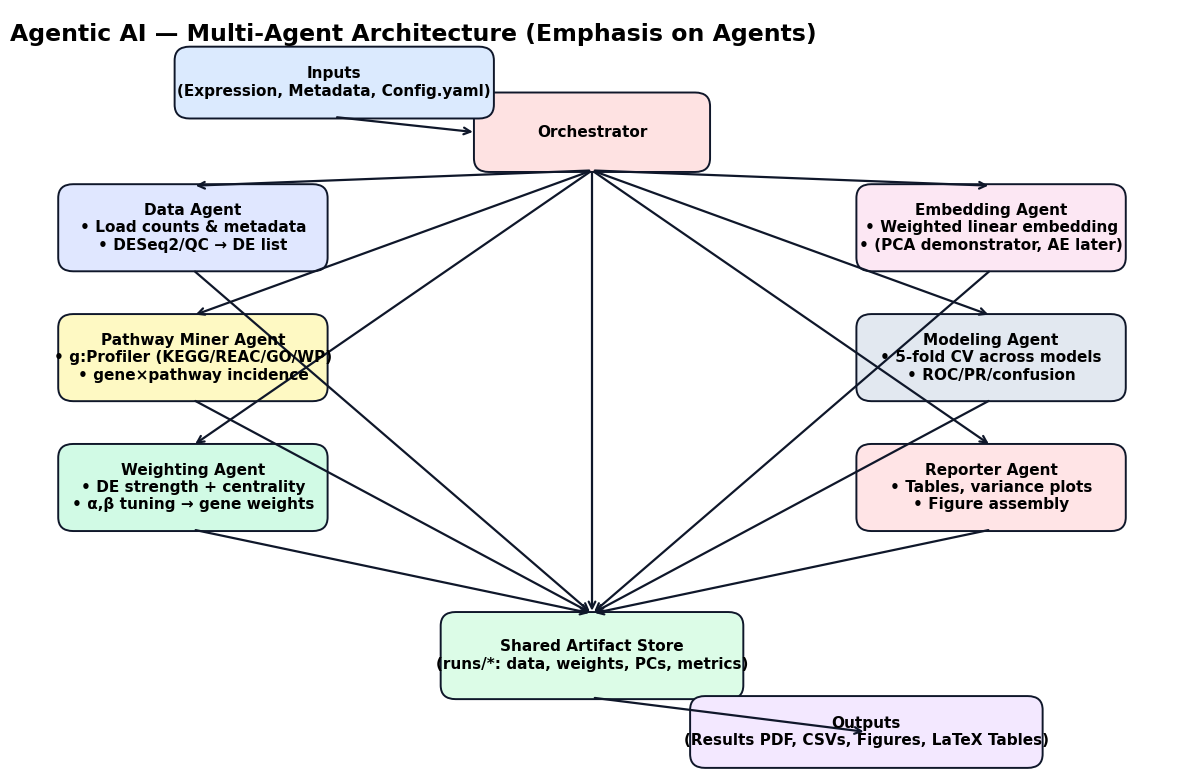

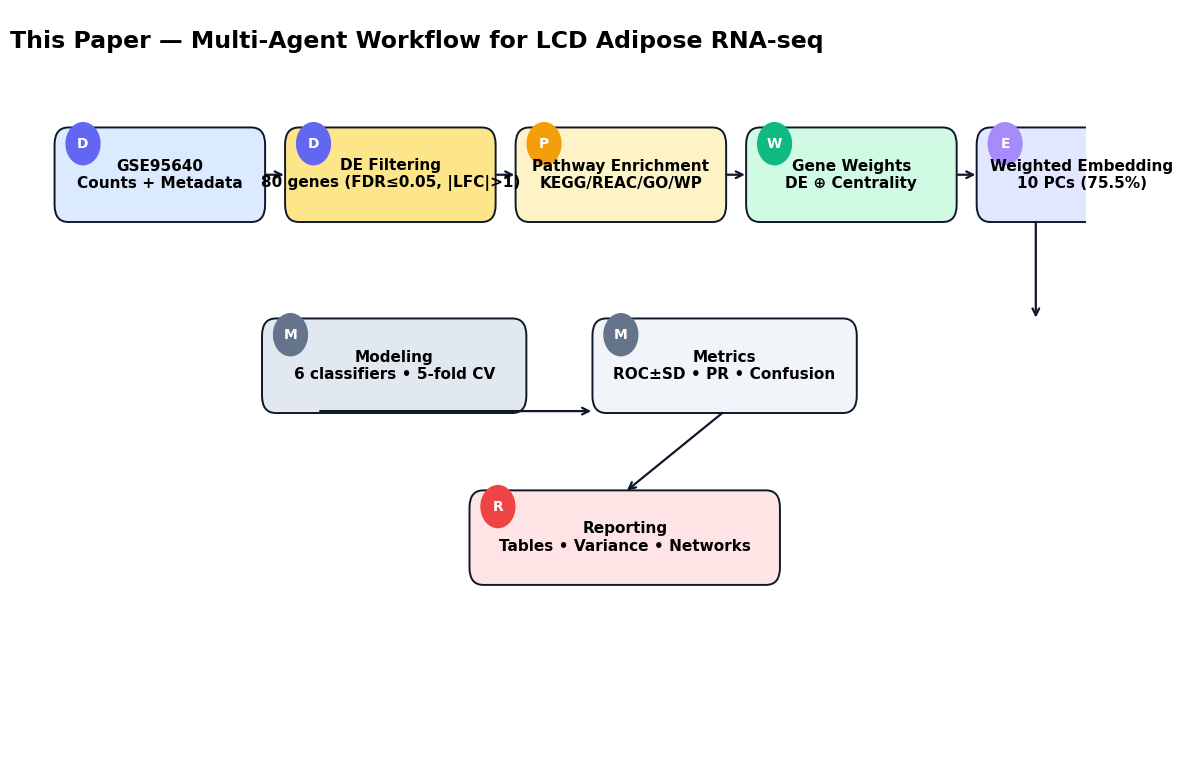

In [5]:
# Rebuild figures per request, emphasizing agents first, then the case-specific workflow.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from matplotlib import patheffects as pe

plt.rcParams.update({
    "figure.figsize": (12, 8),
    "font.size": 12,
    "axes.axisbelow": True
})

def rounded_box(ax, xy, w, h, text, fc="#F8FAFC", ec="#0F172A", lw=1.4, radius=0.18, txtsize=11, bold=False):
    x, y = xy
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle=f"round,pad=0.02,rounding_size={radius}",
                         linewidth=lw, edgecolor=ec, facecolor=fc)
    ax.add_patch(box)
    kw = dict(ha="center", va="center", fontsize=txtsize)
    if bold:
        kw["fontweight"] = "bold"
    ax.text(x + w/2, y + h/2, text, **kw)
    return box

def arrow(ax, start, end, color="#0F172A", lw=1.6, style="->", rad=0.0):
    a = FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=12,
                        linewidth=lw, color=color, connectionstyle=f"arc3,rad={rad}")
    ax.add_patch(a)
    return a

# ===== Figure A: Multi-Agent Architecture (emphasis on agents) =====
figA, axA = plt.subplots()
axA.set_xlim(0, 14)
axA.set_ylim(0, 10)
axA.axis("off")

axA.text(0, 9.6, "Agentic AI — Multi‑Agent Architecture (Emphasis on Agents)", fontsize=17, fontweight="bold")

# Orchestrator
orch = rounded_box(axA, (5.6, 7.9), 2.8, 1.0, "Orchestrator", fc="#FEE2E2", bold=True)

# Shared Artifact Store
store = rounded_box(axA, (5.2, 1.0), 3.6, 1.1, "Shared Artifact Store\n(runs/*: data, weights, PCs, metrics)", fc="#DCFCE7", bold=True)

# Agents arranged around orchestrator
w, h = 3.2, 1.1
a1 = rounded_box(axA, (0.6, 6.6), w, h, "Data Agent\n• Load counts & metadata\n• DESeq2/QC → DE list", fc="#E0E7FF", bold=True)
a2 = rounded_box(axA, (0.6, 4.9), w, h, "Pathway Miner Agent\n• g:Profiler (KEGG/REAC/GO/WP)\n• gene×pathway incidence", fc="#FEF9C3", bold=True)
a3 = rounded_box(axA, (0.6, 3.2), w, h, "Weighting Agent\n• DE strength + centrality\n• α,β tuning → gene weights", fc="#D1FAE5", bold=True)
a4 = rounded_box(axA, (10.2, 6.6), w, h, "Embedding Agent\n• Weighted linear embedding\n• (PCA demonstrator, AE later)", fc="#FCE7F3", bold=True)
a5 = rounded_box(axA, (10.2, 4.9), w, h, "Modeling Agent\n• 5-fold CV across models\n• ROC/PR/confusion", fc="#E2E8F0", bold=True)
a6 = rounded_box(axA, (10.2, 3.2), w, h, "Reporter Agent\n• Tables, variance plots\n• Figure assembly", fc="#FFE4E6", bold=True)

# Connect agents to orchestrator
for bx in [a1,a2,a3,a4,a5,a6]:
    # from orchestrator to agent
    arrow(axA, (7.0, 7.9), (bx.get_bbox().x0 + w/2, bx.get_bbox().y1), rad=0.0)
    # from agent to store
    arrow(axA, (bx.get_bbox().x0 + w/2, bx.get_bbox().y0), (7.0, 2.1), rad=0.0)

# Connect orchestrator to store (read/write)
arrow(axA, (7.0, 7.9), (7.0, 2.1))

# Input/Output cloud boxes
inp = rounded_box(axA, (2.0, 8.6), 3.8, 0.9, "Inputs\n(Expression, Metadata, Config.yaml)", fc="#DBEAFE", bold=True)
outp = rounded_box(axA, (8.2, 0.1), 4.2, 0.9, "Outputs\n(Results PDF, CSVs, Figures, LaTeX Tables)", fc="#F3E8FF", bold=True)

arrow(axA, (3.9, 8.6), (5.6, 8.4))  # inputs -> orchestrator
arrow(axA, (7.0, 1.0), (10.3, 0.55))  # store -> outputs

figA.tight_layout()
figA_png = output_dir+"/agentic_multi_agent_architecture.png"
figA_pdf = output_dir+"/agentic_multi_agent_architecture.pdf"
figA.savefig(figA_png, dpi=300, bbox_inches="tight")
figA.savefig(figA_pdf, bbox_inches="tight")

# ===== Figure B: Case-Specific Workflow (this paper) =====
figB, axB = plt.subplots()
axB.set_xlim(0, 14)
axB.set_ylim(0, 8)
axB.axis("off")

axB.text(0, 7.6, "This Paper — Multi‑Agent Workflow for LCD Adipose RNA‑seq", fontsize=17, fontweight="bold")

# Row of steps with agent tags (badges)
def agent_badge(ax, center, label, color="#0EA5E9"):
    x,y = center
    circ = Circle((x,y), 0.22, color=color)
    ax.add_patch(circ)
    ax.text(x, y, label, color="white", ha="center", va="center", fontsize=10, fontweight="bold")

x0, y0, w, h = 0.6, 5.8, 2.7, 0.95
b1 = rounded_box(axB, (x0, y0), w, h, "GSE95640\nCounts + Metadata", fc="#DBEAFE", bold=True)
agent_badge(axB, (x0+0.35, y0+h-0.15), "D", "#6366F1")

b2 = rounded_box(axB, (x0+3.0, y0), w, h, "DE Filtering\n80 genes (FDR≤0.05, |LFC|>1)", fc="#FDE68A", bold=True)
agent_badge(axB, (x0+3.35, y0+h-0.15), "D", "#6366F1")

b3 = rounded_box(axB, (x0+6.0, y0), w, h, "Pathway Enrichment\nKEGG/REAC/GO/WP", fc="#FEF3C7", bold=True)
agent_badge(axB, (x0+6.35, y0+h-0.15), "P", "#F59E0B")

b4 = rounded_box(axB, (x0+9.0, y0), w, h, "Gene Weights\nDE ⊕ Centrality", fc="#D1FAE5", bold=True)
agent_badge(axB, (x0+9.35, y0+h-0.15), "W", "#10B981")

b5 = rounded_box(axB, (x0+12.0, y0), w, h, "Weighted Embedding\n10 PCs (75.5%)", fc="#E0E7FF", bold=True)
agent_badge(axB, (x0+12.35, y0+h-0.15), "E", "#A78BFA")

# arrows row
for i in range(5):
    if i<4:
        arrow(axB, (x0 + i*3.0 + w, y0 + h/2), (x0 + (i+1)*3.0, y0 + h/2))

# Second row: evaluation & reporting
b6 = rounded_box(axB, (3.3, 3.8), 3.4, 0.95, "Modeling\n6 classifiers • 5-fold CV", fc="#E2E8F0", bold=True)
agent_badge(axB, (3.3+0.35, 3.8+0.95-0.15), "M", "#64748B")

b7 = rounded_box(axB, (7.6, 3.8), 3.4, 0.95, "Metrics\nROC±SD • PR • Confusion", fc="#F1F5F9", bold=True)
agent_badge(axB, (7.6+0.35, 3.8+0.95-0.15), "M", "#64748B")

b8 = rounded_box(axB, (6.0, 2.0), 4.0, 0.95, "Reporting\nTables • Variance • Networks", fc="#FFE4E6", bold=True)
agent_badge(axB, (6.0+0.35, 2.0+0.95-0.15), "R", "#EF4444")

# connectors
arrow(axB, (12.0+2.7/2, 5.8), (12.0+2.7/2, 4.75))
arrow(axB, (4.0, 3.8), (7.6, 3.8))
arrow(axB, (9.3, 3.8), (8.0, 2.95))

figB.tight_layout()
figB_png = output_dir+"/agentic_multi_agent_workflow.png"
figB_pdf = output_dir+"/agentic_multi_agent_workflow.pdf"
figB.savefig(figB_png, dpi=300, bbox_inches="tight")
figB.savefig(figB_pdf, bbox_inches="tight")

(figA_png, figA_pdf, figB_png, figB_pdf)


Enhanced LLM-Orchestrated Agentic AI Architecture created:
PNG: ../results/workflow_architecture/enhanced_agentic_llm_architecture.png
PDF: ../results/workflow_architecture/enhanced_agentic_llm_architecture.pdf


('../results/workflow_architecture/enhanced_agentic_llm_architecture.png',
 '../results/workflow_architecture/enhanced_agentic_llm_architecture.pdf')

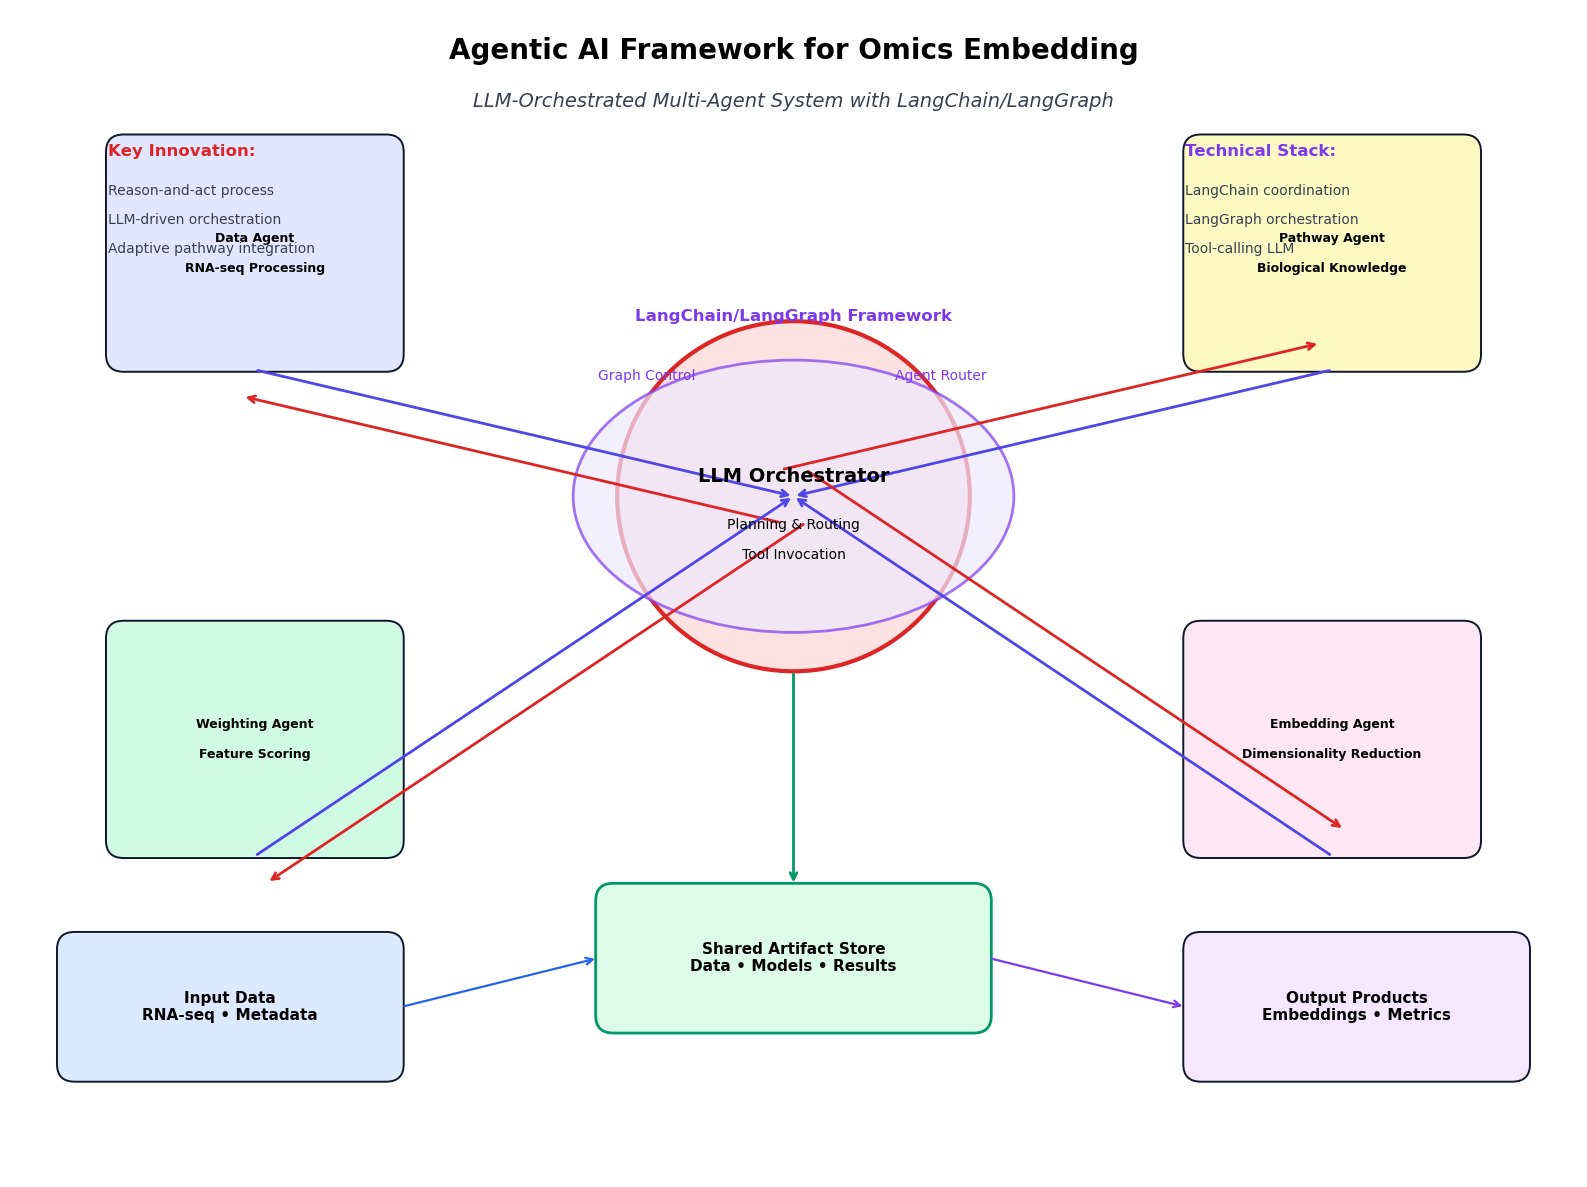

In [8]:
# Enhanced Agentic AI Framework Architecture - Emphasizing LLM Orchestration
# This figure highlights the LLM backbone with LangChain/LangGraph coordination

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Ellipse
from matplotlib import patheffects as pe
import numpy as np

plt.rcParams.update({
    "figure.figsize": (16, 12),
    "font.size": 11,
    "axes.axisbelow": True
})

def rounded_box(ax, xy, w, h, text, fc="#F8FAFC", ec="#0F172A", lw=1.4, radius=0.18, txtsize=11, bold=False):
    x, y = xy
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle=f"round,pad=0.02,rounding_size={radius}",
                         linewidth=lw, edgecolor=ec, facecolor=fc)
    ax.add_patch(box)
    kw = dict(ha="center", va="center", fontsize=txtsize)
    if bold:
        kw["fontweight"] = "bold"
    ax.text(x + w/2, y + h/2, text, **kw)
    return box

def arrow(ax, start, end, color="#0F172A", lw=1.6, style="->", rad=0.0):
    a = FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=12,
                        linewidth=lw, color=color, connectionstyle=f"arc3,rad={rad}")
    ax.add_patch(a)
    return a

# ===== Enhanced Figure: LLM-Orchestrated Agentic AI Framework =====
fig, ax = plt.subplots()
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis("off")

# Main title
ax.text(8, 11.5, "Agentic AI Framework for Omics Embedding", 
        fontsize=20, fontweight="bold", ha="center")
ax.text(8, 11.0, "LLM-Orchestrated Multi-Agent System with LangChain/LangGraph", 
        fontsize=14, ha="center", style="italic", color="#374151")

# Central LLM Orchestrator (Large prominent circle)
llm_center = (8, 7)
llm_radius = 1.8
llm_circle = Circle(llm_center, llm_radius, facecolor="#FEE2E2", edgecolor="#DC2626", linewidth=3)
ax.add_patch(llm_circle)

# LLM core text
ax.text(llm_center[0], llm_center[1]+0.2, "LLM Orchestrator", 
        fontsize=14, fontweight="bold", ha="center", va="center")
ax.text(llm_center[0], llm_center[1]-0.3, "Planning & Routing", 
        fontsize=10, ha="center", va="center")
ax.text(llm_center[0], llm_center[1]-0.6, "Tool Invocation", 
        fontsize=10, ha="center", va="center")

# LangChain/LangGraph Framework (surrounding the LLM)
framework_ellipse = Ellipse(llm_center, 4.5, 2.8, facecolor="#EDE9FE", 
                           edgecolor="#7C3AED", linewidth=2, alpha=0.7)
ax.add_patch(framework_ellipse)

ax.text(llm_center[0], llm_center[1]+1.8, "LangChain/LangGraph Framework", 
        fontsize=12, fontweight="bold", ha="center", color="#7C3AED")
ax.text(llm_center[0]-1.5, llm_center[1]+1.2, "Graph Control", 
        fontsize=10, ha="center", color="#7C3AED")
ax.text(llm_center[0]+1.5, llm_center[1]+1.2, "Agent Router", 
        fontsize=10, ha="center", color="#7C3AED")

# Four Core Agents positioned around the framework
agent_positions = [
    (2.5, 9.5, "Data Agent", "#E0E7FF", 
     "RNA-seq Processing"),
    (13.5, 9.5, "Pathway Agent", "#FEF9C3", 
     "Biological Knowledge"),
    (2.5, 4.5, "Weighting Agent", "#D1FAE5", 
     "Feature Scoring"),
    (13.5, 4.5, "Embedding Agent", "#FCE7F3", 
     "Dimensionality Reduction")
]

agent_boxes = []
for x, y, title, color, description in agent_positions:
    box = rounded_box(ax, (x-1.5, y-1.2), 3.0, 2.4, f"{title}\n\n{description}", 
                     fc=color, bold=True, txtsize=9)
    agent_boxes.append((box, x, y))
    
    # Bidirectional arrows between agents and LLM orchestrator
    # Agent to LLM
    arrow(ax, (x, y-1.2), llm_center, color="#4F46E5", lw=2)
    # LLM to Agent (with slight offset)
    theta = np.arctan2(y - llm_center[1], x - llm_center[0])
    offset_x = 0.3 * np.cos(theta + np.pi/2)
    offset_y = 0.3 * np.sin(theta + np.pi/2)
    arrow(ax, (llm_center[0] + offset_x, llm_center[1] + offset_y), 
          (x + offset_x, y-1.2 + offset_y), color="#DC2626", lw=2)

# Shared Knowledge Base / Artifact Store
knowledge_store = rounded_box(ax, (6, 1.5), 4, 1.5, 
                            "Shared Artifact Store\nData • Models • Results", 
                            fc="#DCFCE7", ec="#059669", lw=2, bold=True)

# Connect LLM to knowledge store
arrow(ax, (llm_center[0], llm_center[1]-llm_radius), (8, 3.0), color="#059669", lw=2)

# Input and Output boxes
input_box = rounded_box(ax, (0.5, 1.0), 3.5, 1.5, 
                       "Input Data\nRNA-seq • Metadata", 
                       fc="#DBEAFE", bold=True)

output_box = rounded_box(ax, (12, 1.0), 3.5, 1.5, 
                        "Output Products\nEmbeddings • Metrics", 
                        fc="#F3E8FF", bold=True)

# Connect inputs/outputs to knowledge store
arrow(ax, (4.0, 1.75), (6.0, 2.25), color="#2563EB")
arrow(ax, (10.0, 2.25), (12.0, 1.75), color="#7C3AED")

# Add key innovation callouts
ax.text(1, 10.5, "Key Innovation:", fontsize=12, fontweight="bold", color="#DC2626")
ax.text(1, 10.1, "Reason-and-act process", fontsize=10, color="#374151")
ax.text(1, 9.8, "LLM-driven orchestration", fontsize=10, color="#374151")
ax.text(1, 9.5, "Adaptive pathway integration", fontsize=10, color="#374151")

# Technical infrastructure notes
ax.text(12, 10.5, "Technical Stack:", fontsize=12, fontweight="bold", color="#7C3AED")
ax.text(12, 10.1, "LangChain coordination", fontsize=10, color="#374151")
ax.text(12, 9.8, "LangGraph orchestration", fontsize=10, color="#374151")
ax.text(12, 9.5, "Tool-calling LLM", fontsize=10, color="#374151")

fig.tight_layout()
fig_enhanced_png = output_dir+"/enhanced_agentic_llm_architecture.png"
fig_enhanced_pdf = output_dir+"/enhanced_agentic_llm_architecture.pdf"
fig.savefig(fig_enhanced_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_enhanced_pdf, bbox_inches="tight")

print("Enhanced LLM-Orchestrated Agentic AI Architecture created:")
print(f"PNG: {fig_enhanced_png}")
print(f"PDF: {fig_enhanced_pdf}")

(fig_enhanced_png, fig_enhanced_pdf)